In [1]:
import itertools
import functools
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import scipy.ndimage
from tqdm import tqdm
import xarray as xr

from fluxoniumcr import DATA_DIR
from fluxoniumcr.plotting.cookbook import colorline, plot_triangle, imshow_heatmap
from fluxoniumcr.qubits.fluxonium import Fluxonium
from fluxoniumcr.utils import load_arguments

plt.style.use("fluxoniumcr.plotting.paper")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi']= 200

In [2]:
from matplotlib.colors import LinearSegmentedColormap


myblues = LinearSegmentedColormap.from_list(
    "myblues",
    [
#         "#deebf7",
        "#c6dbef",
        "#9ecae1",
        "#6baed6",
        "#4292c6",
        "#2171b5",
        "#08519c",
        "#08306b",
    ]
)


class MySquircleHandle:
    def __init__(self, ellipse_factor, ratio, facecolor):
        self.ellipse_factor = ellipse_factor
        self.ratio = ratio
        self.facecolor = facecolor


class HandlerMySquircle(mpl.legend_handler.HandlerBase):
    def create_artists(
            self,
            legend,
            orig_handle,
            xdescent,
            ydescent,
            width,
            height,
            fontsize,
            trans,
    ):
        center = (
            xdescent + width/2,
            ydescent + height/2,
        )
        size = (width, height)
        
        artists = []
        
        for (ratio, fc) in zip(orig_handle.ratio, orig_handle.facecolor):
            xy = create_squircle_vertices(
                center,
                size,
                orig_handle.ellipse_factor,
                ratio,
            )
            patch = mpl.patches.Polygon(
                xy,
                facecolor=fc,
                transform=trans,
            )
            artists.append(patch)

        return artists

def create_squircle_vertices(
        center,
        size,
        ellipse_factor,
        ratio,
):
    theta = np.linspace(0, np.pi/2, 10, endpoint=False)

    quarter = np.column_stack([np.cos(theta)**ratio, np.sin(theta)**ratio])
    vertices = np.concatenate([
        quarter,
        (-1, 1) * quarter[::-1],
        (-1, -1) * quarter,
        (1, -1) * quarter[::-1][:-1],
    ])
    vertices *= (1 - ratio*(1 - ellipse_factor))

    half_size = (size[0]/2, size[1]/2)
    vertices = center + half_size * vertices
    
    return vertices

In [3]:
parent_path = DATA_DIR/"control_qubit_collisions/EJ=4.00,EC=1.20,EL=0.40"
argm = load_arguments(parent_path)

In [4]:
dataset = xr.load_dataset(parent_path/"planck.hdf5")

In [5]:
fx = Fluxonium(
    EJ=argm.EJ,
    EC=argm.EC,
    EL=argm.EL,
    dim=argm.levels,
    cutoff=128,
    flux=0.5,
)

n_op = fx.get_operator('charge')
E = fx.eigenvalues

In [6]:
# Filter away very sharp peaks
dataset['transition_probability_filtered'] = xr.apply_ufunc(
    lambda y: scipy.ndimage.minimum_filter1d(y, 4, mode='nearest'),
    dataset.transition_probability,
    input_core_dims=[['frequency']],
    output_core_dims=[['frequency']],
)

dataset['leakage_probability'] = xr.DataArray(
    0.0,
    coords=[
        dataset.frequency,
        dataset.deltap,
        dataset.ramp_duration,
        dataset.ket,
    ]
)

for ket in dataset.ket.data:
    ds = dataset.loc[dict(ket=ket)]
    bra = list(ds.bra.data)
    bra.remove(ket)
    ds.leakage_probability[:] = ds.transition_probability_filtered.sel(bra=bra).sum('bra')

In [7]:
transition_peaks = {}

ramp_duration = 20
deltap = 1.0
min_peak_height = 5e-5

print("(n, i, j)\tFreq. [GHz] \tDetuning [MHz]:")
for ket in [0, 1]:
    ds = dataset.sel(
        ramp_duration=ramp_duration,
        deltap=deltap,
        ket=ket,
    )
    for bra in ds.bra.data:
        if bra == ket: continue
        prob = ds.transition_probability_filtered.sel(bra=bra)
        peak_indices, peak_properties = scipy.signal.find_peaks(
            prob.data,
            height=min_peak_height,
        )
        peak_prominences, *_ = scipy.signal.peak_prominences(
            np.log10(prob.data),
            peak_indices,
        )

        # Keep only peaks with prominences at least 10x the contour
        mask = peak_prominences > 1

        peak_indices = peak_indices[mask]
        peak_freqs = ds.frequency.data[peak_indices]
        peak_heights = peak_properties['peak_heights'][mask]

        for freq, height in zip(peak_freqs, peak_heights):
            bare_freq = E[bra] - E[ket]
            if (bra - ket) % 2 == 0:
                harmonic = round(bare_freq/freq/2)*2
            else:
                harmonic = round((bare_freq/freq - 1)/2)*2 + 1
            transition_peaks[(harmonic, int(bra), int(ket))] = (freq, height, bare_freq)
            print(
                f"({harmonic}, {bra}, {ket})\t",
                "{:+.3g}\t\t {:+.3g}".format(
                    freq/(2*pi),
                    (freq - bare_freq/harmonic)*1e3/(2*pi)
                ),
            )

(n, i, j)	Freq. [GHz] 	Detuning [MHz]:
(4, 2, 0)	 +1.04		 -27.9
(5, 3, 0)	 +1.24		 +7.55
(6, 4, 0)	 +1.52		 -0.328
(5, 2, 1)	 +0.801		 +1.95
(3, 2, 1)	 +1.3		 -27.7
(4, 3, 1)	 +1.52		 +45.4
(7, 4, 1)	 +1.28		 +14
(8, 5, 1)	 +1.48		 +74.4


In [9]:
heatmap_dataset = xr.load_dataset(
    DATA_DIR/"charge_operator/EJ=4.00,EC=1.20,EL=0.40/driven_charge_operator.hdf5"
)
amp_from_deltap_dataset = xr.load_dataset(
    DATA_DIR/"charge_operator/EJ=4.00,EC=1.20,EL=0.40/amplitude_from_deltap.hdf5"
)
ac_dataset = xr.load_dataset(
    DATA_DIR/"charge_operator/EJ=4.00,EC=1.20,EL=0.40/crossings.hdf5"
)

In [10]:
nF100_data = heatmap_dataset.isel(harmonic=-1, bra=0, ket=0).matrix.data
nF111_data = heatmap_dataset.isel(harmonic=-1, bra=1, ket=1).matrix.data
heatmap_x = heatmap_dataset.frequency.data
heatmap_y = heatmap_dataset.amplitude.data
heatmap_data = abs(nF111_data - nF100_data).T/abs(n_op[0, 1])

Ω0 = amp_from_deltap_dataset.amplitude.attrs['plot_unit']

In [11]:
from fluxoniumcr.plotting.collision_heatmap import mycmap

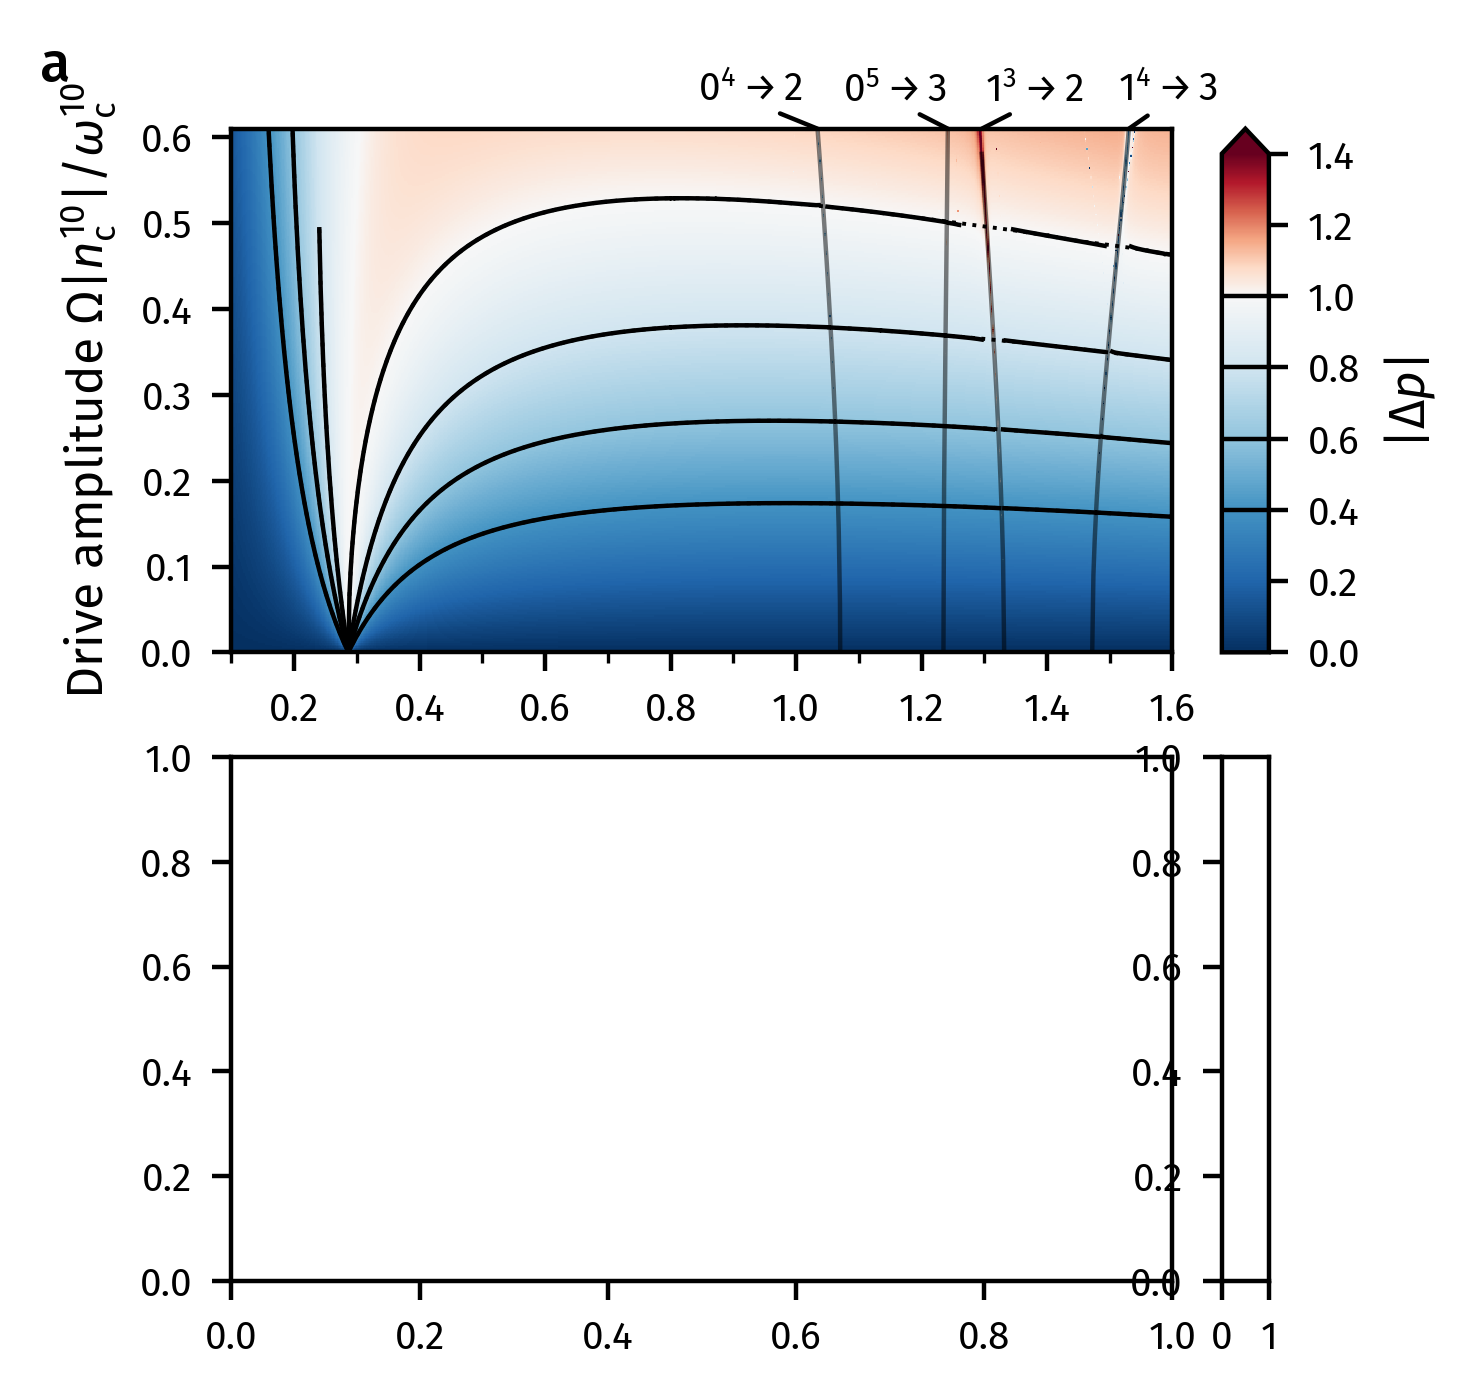

In [12]:
fig = plt.figure(
    figsize=(85/25.4, 95/25.4),
)
axs = fig.subplots(
    nrows=2,
    ncols=2,
    width_ratios=(100, 5),
    gridspec_kw=dict(wspace=0.1),
)

ax = axs[0, 0]
cax = axs[0, 1]

ax.clear()
cax.clear()

hm = ax.pcolormesh(
    heatmap_x,
    heatmap_y,
    heatmap_data,
    rasterized=True,
    cmap=mycmap,
    norm=mpl.colors.TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=1.4),
)
cb = fig.colorbar(hm, cax=cax, label="$|\Delta p|$", extend='max')
cb.ax.set_yscale('linear')

# deltap_primary = np.array([0.2, 0.4, 0.6, 0.8, 1.0])
deltap_primary = np.arange(1, 11)/10
deltap_secondary = 1.0

internal_bin_edges = (deltap_primary[1:] + deltap_primary[:-1])/2
bin_edges = [
    2*deltap_primary[0] - internal_bin_edges[0],
    *internal_bin_edges,
    2*deltap_primary[-1] - internal_bin_edges[-1],
]
mappable = plt.cm.ScalarMappable(
    mpl.colors.BoundaryNorm(bin_edges, myblues.N),
    cmap=myblues.reversed(),
)

annotation_color = 'black'

for deltap in [1.0, 0.8, 0.6, 0.4]:
    color = 'black'
    ds = amp_from_deltap_dataset.sel(deltap=deltap)
    
    ax.plot(
        ds.frequency,
        ds.amplitude_spline,
        c=color,
        ls=':',
        lw=0.7,
        alpha=1.0,
    )
    
    mask = ds.amplitude_valid.data.copy()
    
    # The avoided crossings at low frequencies are very small, so just ignore them
    # to reduce artifacts.
    mask[ds.frequency < 0.6 * 2*pi] = True
    
    x = list(ds.frequency.data)
    y = list(ds.amplitude.where(mask).data)
    x.insert(0, E[1] - E[0])
    y.insert(0, 0.0)
    idx = np.argsort(x)
    x = np.take(x, idx)
    y = np.take(y, idx)
    
    ax.plot(x, y, c=color, lw=0.8)
    cax.axhline(deltap, c=color, lw=0.8)

ax.set_xlim(0.1 * 2*pi, 1.6 * 2*pi)
ax.set_ylim(0, 0.61*Ω0)

for harmonic, bra, ket in [
        (4, 3, 1),
        (3, 2, 1),
        (5, 3, 0),
        (4, 2, 0),
]:
    transition_index = np.flatnonzero(
        (ac_dataset.harmonic == harmonic)
        & (ac_dataset.bra == bra)
        & (ac_dataset.ket == ket)
    )[0]
    ds = ac_dataset.sel(dim_0=ac_dataset.transition_index==transition_index)
    ds = ds.sortby('frequency')
    
    if (harmonic, bra, ket) == (3, 2, 1):
        # Special case, ignore high amplitude avoided crossings.
        ds = ds.sel(dim_0=ds.amplitude<13.6)

    ax.plot(ds.frequency, ds.amplitude, c='black', ls='-', lw=0.8, alpha=0.5)
    
    idx = np.argsort(ds.amplitude.data)
    x_position = np.interp(ax.get_ylim()[1], ds.amplitude.data[idx], ds.frequency.data[idx])
    
    xytext= (0, 3.5)
    
    if (harmonic, bra, ket) == (4, 3, 1):
        xytext= (7, xytext[1])
    elif (harmonic, bra, ket) == (5, 3, 0):
        xytext = (-9.5, xytext[1])
    elif (harmonic, bra, ket) == (3, 2, 1):
        xytext = (9.5, xytext[1])
    elif (harmonic, bra, ket) == (4, 2, 0):
        xytext = (-12, xytext[1])
    
    ax.annotate(
        rf"${ket}^{harmonic}\rightarrow{bra}$",
        (x_position, ax.get_ylim()[1]),
        xytext=xytext,
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=plt.rcParams['xtick.labelsize'],
        arrowprops=dict(
            arrowstyle='-',
            lw=plt.rcParams['xtick.major.width'],
            ec=annotation_color,
            shrinkA=2,
            shrinkB=0,
            relpos=(0.5, 0.2),
        ),
        bbox=dict(boxstyle='square,pad=0.0', lw=0, ec='none', fc='none'),
    )

ax.set_xticks(np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]) * 2*pi)
ax.set_xticks(np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5]) * 2*pi, minor=True)
ax.set_yticks(np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]) * Ω0)

ax.xaxis.set_major_formatter(lambda x, p: x/(2*pi))
ax.yaxis.set_major_formatter(lambda y, p: "{:.1f}".format(y/Ω0))

ax.set_ylabel("Drive amplitude " + r"$\Omega |n^{10}_\mathrm{c}|/\omega^{10}_\mathrm{c}$")

cax.set_ylim(0, 1.4)
cax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4])

# ax.annotate(
#     r"$0^5\rightarrow3$",
#     (1.25 * 2*pi, ax.get_ylim()[1]),
#     xytext=(-11, 3.5),
#     textcoords='offset points',
#     ha='center',
#     va='bottom',
#     fontsize=plt.rcParams['xtick.labelsize'],
#     arrowprops=dict(
#         arrowstyle='-',
#         lw=0.8,
#         ec=annotation_color,
#         shrinkA=0,
#         shrinkB=0,
#         relpos=(0.5, 0.2),
#     ),
#     bbox=dict(boxstyle='square,pad=0', lw=0, ec='none', fc='none'),
# )
# ax.annotate(
#     r"$1^3\rightarrow2$",
#     (1.28 * 2*pi, ax.get_ylim()[1]),
#     xytext=(11, 3.5),
#     textcoords='offset points',
#     ha='center',
#     va='bottom',
#     fontsize=plt.rcParams['xtick.labelsize'],
#     arrowprops=dict(
#         arrowstyle='-',
#         lw=0.8,
#         ec=annotation_color,
#         shrinkA=0,
#         shrinkB=0,
#         relpos=(0.5, 0.2),
#     ),
#     bbox=dict(boxstyle='square,pad=0', lw=0, ec='none', fc='none'),
# )

def add_subfig_label(ax, subfig_label, xytext):
    annotation = ax.annotate(
        subfig_label,
        (0.00, 1.00),
        xytext,
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="right",
        va="top",
        zorder=1,
    )
    
    return annotation

add_subfig_label(ax, "a", xytext=(-29, 16))

plt.show()

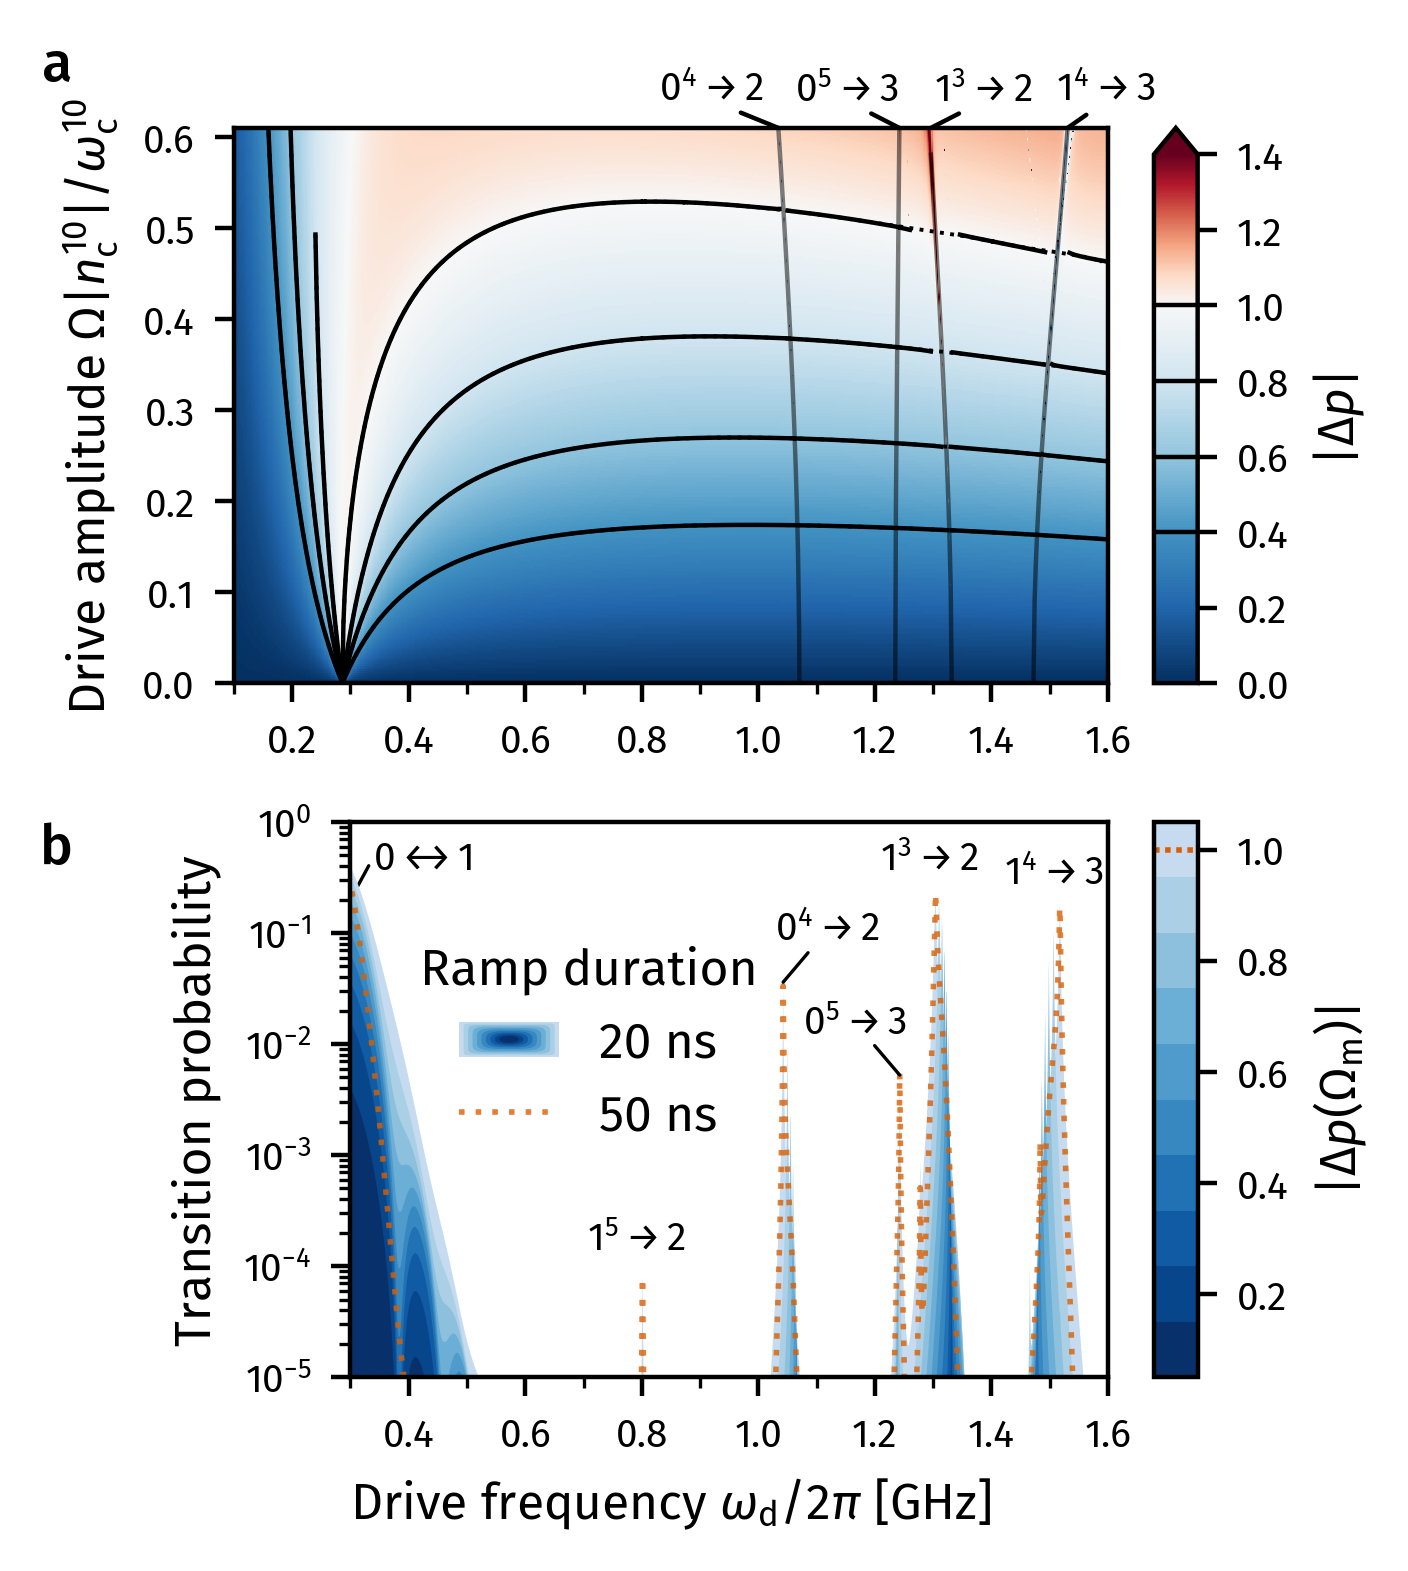

In [13]:
# fig = plt.figure(
# #     figsize=(85/25.4, 50/25.4),
#     figsize=(75/25.4, 50/25.4),
# )
# ax, cax = fig.subplots(
#     nrows=1,
#     ncols=2,
#     width_ratios=(100, 5),
#     gridspec_kw=dict(wspace=0.1),
# )

ax, cax = axs[1, :]
ax.clear()
cax.clear()

clip_box = mpl.transforms.TransformedBbox(
    mpl.transforms.Bbox([
        [0.3 * 2*pi, 1e-5],
        [1.6 * 2*pi, 1e-0],
    ]),
    ax.transData,
)

ramp_duration_primary = 20
ramp_duration_secondary = 50

for deltap in sorted(deltap_primary, reverse=True):
    ds = dataset.sel(deltap=deltap, ramp_duration=ramp_duration_primary)
    polycol = ax.fill_between(
        ds.frequency,
        ds.leakage_probability.sel(ket=[0, 1]).mean('ket'),
        fc=mappable.to_rgba(deltap),
    )
    polycol.set_clip_box(clip_box)

    
ds = dataset.sel(deltap=deltap_secondary, ramp_duration=ramp_duration_secondary)
secondary_lines = ax.plot(
    ds.frequency,
    ds.leakage_probability.sel(ket=[0, 1]).mean('ket'),
    c='C1',
    zorder=2,
    ls=(0, (1, 2)),
    alpha=0.8,
)
secondary_lines[0].set_clip_box(clip_box)

cax.axhline(deltap_secondary, c='C1', ls=(0, (1, 1)))
# cax.add_patch(mpl.patches.Rectangle(
#     (0.07, deltap_secondary - 0.096),
#     width=0.86,
#     height=0.189,
#     ls=(0, (1, 1.5)),
#     fc='none',
#     ec='C1',
#     zorder=2,
# ))

ax.legend(
    [
        MySquircleHandle(
            ellipse_factor=0.2,
            ratio=(
                (
                    deltap_primary.max()
                    - sorted(deltap_primary, reverse=True)
                )
                / np.ptp(deltap_primary)
            ),
            facecolor=mappable.to_rgba(sorted(deltap_primary, reverse=True)),
            
        ),
        secondary_lines[0],
    ],
    [
        f"{ramp_duration_primary} ns",
        f"{ramp_duration_secondary} ns",
    ],
    handler_map={MySquircleHandle: HandlerMySquircle()},
    title="Ramp duration",
    loc='upper left',
    bbox_to_anchor=(0.161, 0.86),
)

ax.set_yscale('log')
ax.set_xlim(0.1 * 2*pi, 1.6 * 2*pi)
ax.set_ylim(1e-5, 1)

ax.xaxis.set_major_formatter(lambda x, p: x/(2*pi))

ax.set_ylabel("Transition probability")
ax.set_xlabel(r"Drive frequency $\omega_\mathrm{d}/2\pi$ [GHz]")

ax.set_xticks(np.array([0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6]) * 2*pi)
ax.set_xticks(np.array([0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5]) * 2*pi, minor=True)

plt.colorbar(
    mappable,
    label="$|\Delta p(\Omega_\mathrm{m})|$",
    cax=cax,
)
cax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
cax.set_yticks([], minor=True)
cax.set_ylim(0.05, 1.05)


plt.sca(ax)

markers = [
    ('o', 1),
    ('^', 1),
    ('s', 1),
    ('d', 1),
    ('p', 1),
    ('x', 1),
]
for i, ((n, bra, ket), p) in enumerate(transition_peaks.items()):
    default_arrow_props = dict(
        arrowstyle='-',
        lw=0.6,
        ec=annotation_color,
        shrinkA=0,
        shrinkB=0,
    )
    
    use_arrowprops = None
    xy = (p[0], p[1])
    xytext = (-1, -4)
    
    if (n, bra, ket) in [
            (7, 4, 1),
            (8, 5, 1),
            (6, 4, 0),
    ]:
        continue
    
    if (n, bra, ket) == (5, 3, 0):
        xy = (p[0], p[1]/2)
        xytext = (-8, 6)
        use_arrowprops = default_arrow_props.copy()
        use_arrowprops['relpos'] = (0.5, 0.5)
    if (n, bra, ket) == (4, 2, 0):
        xy = (p[0], p[1]/2)
        xytext = (8, 6)
        use_arrowprops = default_arrow_props.copy()
        use_arrowprops['relpos'] = (0.5, 0.5)
        pass
    if (n, bra, ket) == (7, 4, 1):
        xy = (p[0], p[1]/1.3)
        xytext = (-8, 42)
        use_arrowprops = default_arrow_props.copy()
        use_arrowprops['relpos'] = (0.8, 0)
    if (n, bra, ket) == (3, 2, 1):
        xytext = (-1, -2.5)
        pass
    if (n, bra, ket) == (5, 2, 1):
        xytext = (-1, -2.5)
        pass
#         xy = (p[0], p[1]/2)
#         xytext = (-14, 4)
#         use_arrowprops = default_arrow_props.copy()
#         use_arrowprops['relpos'] = (0, 0.5)
    if (n, bra, ket) == (8, 5, 1):
        xy = (p[0], p[1])
        xytext = (-9, 12)
        use_arrowprops = default_arrow_props.copy()
        use_arrowprops['relpos'] = (0.7, 0)
    if (n, bra, ket) == (6, 4, 0):
        xy = (p[0], p[1])
        xytext = (-14, 0)
        use_arrowprops = default_arrow_props.copy()
        use_arrowprops['relpos'] = (1.0, 0.5)
    
    ax.annotate(
#         f"$f_{{{bra}{ket}}}/{n}$",
        rf"${ket}^{n}\rightarrow{bra}$",
        xy=xy,
        xytext=xytext,
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=7,
        c=annotation_color,
        arrowprops=use_arrowprops,
        bbox=dict(boxstyle='square,pad=0.1', lw=0, ec='none', fc='none'),
    )

ax.annotate(
#     "$f_{10}$",
    r"$0\leftrightarrow1$",
    xy=(0.30*2*pi, 0.2),
    xytext=(4, 4),
    textcoords='offset points',
    ha='left',
    va='bottom',
    fontsize=7,
    c=annotation_color,
    arrowprops=dict(
        arrowstyle='-',
        lw=0.6,
        ec=annotation_color,
        shrinkA=0,
        shrinkB=0,
        relpos=(0, 0.5),
    ),
    bbox=dict(boxstyle='square,pad=0.1', lw=0, ec='none', fc='none'),
    zorder=-1,
)

ax.set_aspect('auto')
ax.spines.left.set_position(('data', 0.3 * 2*pi))
ax.spines.top.set_bounds((0.3 * 2*pi, 1.6 * 2*pi))
ax.spines.bottom.set_bounds((0.3 * 2*pi, 1.6 * 2*pi))

add_subfig_label(ax, "b", xytext=(-29, 0))


fig.subplots_adjust(
    left=0.15,
    bottom=0.105,
    top=0.94,
    right=0.87,
    hspace=0.25,
)

In [14]:
fig.savefig("control_qubit_collisions.pdf")